# 🚀 Model Training - UAV Waterfowl Detection

This notebook trains a YOLOv8 model for detecting waterfowl in thermal UAV imagery.

**Training Configuration:**
- Model: YOLOv8 Nano (fast, good for small objects)
- Epochs: 100 (with early stopping)
- Features: TensorBoard logging, checkpointing, LR scheduling
- Evaluation: Comprehensive metrics and error analysis

## 🔧 Setup and Imports

In [13]:
import sys
from pathlib import Path
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

# Add parent directory to path
sys.path.append('../')

# Import our modules
from models.train import WaterfowlTrainer
from data import config

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✓ Imports successful!
PyTorch version: 2.9.0+cu128
CUDA available: True
GPU: NVIDIA RTX A4000


## 📋 Configuration Review

In [14]:
config.print_config()

CONFIGURATION SUMMARY

Project Root: /home/code/CV_1/notebooks/..
Data Root: /home/code/CV_1/notebooks/../uav_raw

Dataset Splits:
  Train: 70.0%
  Val: 15.0%
  Test: 15.0%

Model Configuration:
  Model: yolov8n.pt
  Input Size: 640
  Epochs: 100
  Batch Size: 16
  Learning Rate: 0.001

Classes: ['waterfowl']


## 🎯 Initialize Trainer

In [15]:
# Create trainer instance
trainer = WaterfowlTrainer(
    model_name=config.YOLO_MODEL,
    experiment_name=None  # Auto-generate with timestamp
)

print(f"\n✓ Trainer initialized!")
print(f"Experiment name: {trainer.experiment_name}")
print(f"Output directory: {trainer.experiment_dir}")


WATERFOWL DETECTION TRAINING
Experiment: waterfowl_yolov8n_20251105_121108
Model: yolov8n.pt
Output directory: /home/code/CV_1/notebooks/../outputs/weights/waterfowl_yolov8n_20251105_121108


✓ Trainer initialized!
Experiment name: waterfowl_yolov8n_20251105_121108
Output directory: /home/code/CV_1/notebooks/../outputs/weights/waterfowl_yolov8n_20251105_121108


## ✅ Verify Setup

Check that:
- GPU is available
- Dataset is properly prepared
- All files are in place

In [16]:
trainer.verify_setup()


VERIFYING SETUP

✓ PyTorch version: 2.9.0+cu128
✓ CUDA available: True
✓ CUDA version: 12.8
✓ GPU device: NVIDIA RTX A4000
✓ GPU memory: 16.76 GB

✓ Data config found: /home/code/CV_1/notebooks/../processed_data/yolo_format/data.yaml

Dataset configuration:
  Path: /home/code/CV_1/notebooks/../processed_data/yolo_format
  Classes: ['waterfowl']
  Num classes: 1
  TRAIN: 378 images, 378 labels
  VAL: 81 images, 81 labels
  TEST: 83 images, 83 labels

✓ All prerequisites verified!


## 📥 Load Pretrained Model

In [17]:
trainer.load_model()


Loading model: yolov8n.pt
✓ Model loaded successfully
  Architecture: YOLOV8N
  Parameters: 3,157,200


## 🚀 Start Training

**This will take 1-2 hours on GPU!**

Training includes:
- Automatic data augmentation
- Learning rate scheduling
- Early stopping (patience=20)
- Model checkpointing
- Validation after each epoch

You can monitor progress with:
- Progress bar (below)
- TensorBoard (optional)
- Metrics printed every epoch

In [18]:
# Train model
success = trainer.train(resume=False)

if success:
    print("\n🎉 Training completed successfully!")
else:
    print("\n⚠️ Training interrupted or failed")


STARTING TRAINING

Training configuration:
  Epochs: 100
  Batch size: 16
  Image size: 640
  Learning rate: 0.001
  Optimizer: AdamW
  Early stopping patience: 20
  Device: 0
  Workers: 8

Augmentation settings:
  hsv_h: 0.015
  hsv_s: 0.3
  hsv_v: 0.4
  degrees: 10
  translate: 0.1
  scale: 0.2
  shear: 0.0
  perspective: 0.0
  flipud: 0.0
  fliplr: 0.5
  mosaic: 1.0
  mixup: 0.0

--------------------------------------------------------------------------------
Training will start in 3 seconds...
Press Ctrl+C to stop training gracefully
--------------------------------------------------------------------------------

Ultralytics 8.3.225 🚀 Python-3.10.12 torch-2.9.0+cu128 CUDA:0 (NVIDIA RTX A4000, 15984MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/cod

## 📊 Training Results

Let's look at the training curves and metrics.

In [19]:
# Get training summary
trainer.get_training_summary()


TRAINING SUMMARY

Generated files:

  Weights (/home/code/CV_1/notebooks/../outputs/weights/waterfowl_yolov8n_20251105_121108/weights):
    - epoch50.pt (17.61 MB)
    - epoch10.pt (17.60 MB)
    - epoch40.pt (17.61 MB)
    - epoch0.pt (17.60 MB)
    - epoch90.pt (17.61 MB)
    - epoch70.pt (17.61 MB)
    - epoch80.pt (17.61 MB)
    - last.pt (5.95 MB)
    - epoch60.pt (17.61 MB)
    - best.pt (5.95 MB)
    - epoch20.pt (17.60 MB)
    - epoch30.pt (17.60 MB)

  Results (/home/code/CV_1/notebooks/../outputs/weights/waterfowl_yolov8n_20251105_121108):
    ✓ results.png
    ✓ results.csv
    ✓ confusion_matrix.png
    ✓ confusion_matrix_normalized.png

--------------------------------------------------------------------------------
Final Metrics (Last Epoch):
--------------------------------------------------------------------------------
  Precision           : 0.8426
  Recall              : 0.8037
  mAP@0.5             : 0.8753
  mAP@0.5:0.95        : 0.4081

✓ Training complete! Proce

### 📈 Visualize Training Curves

Training Curves:


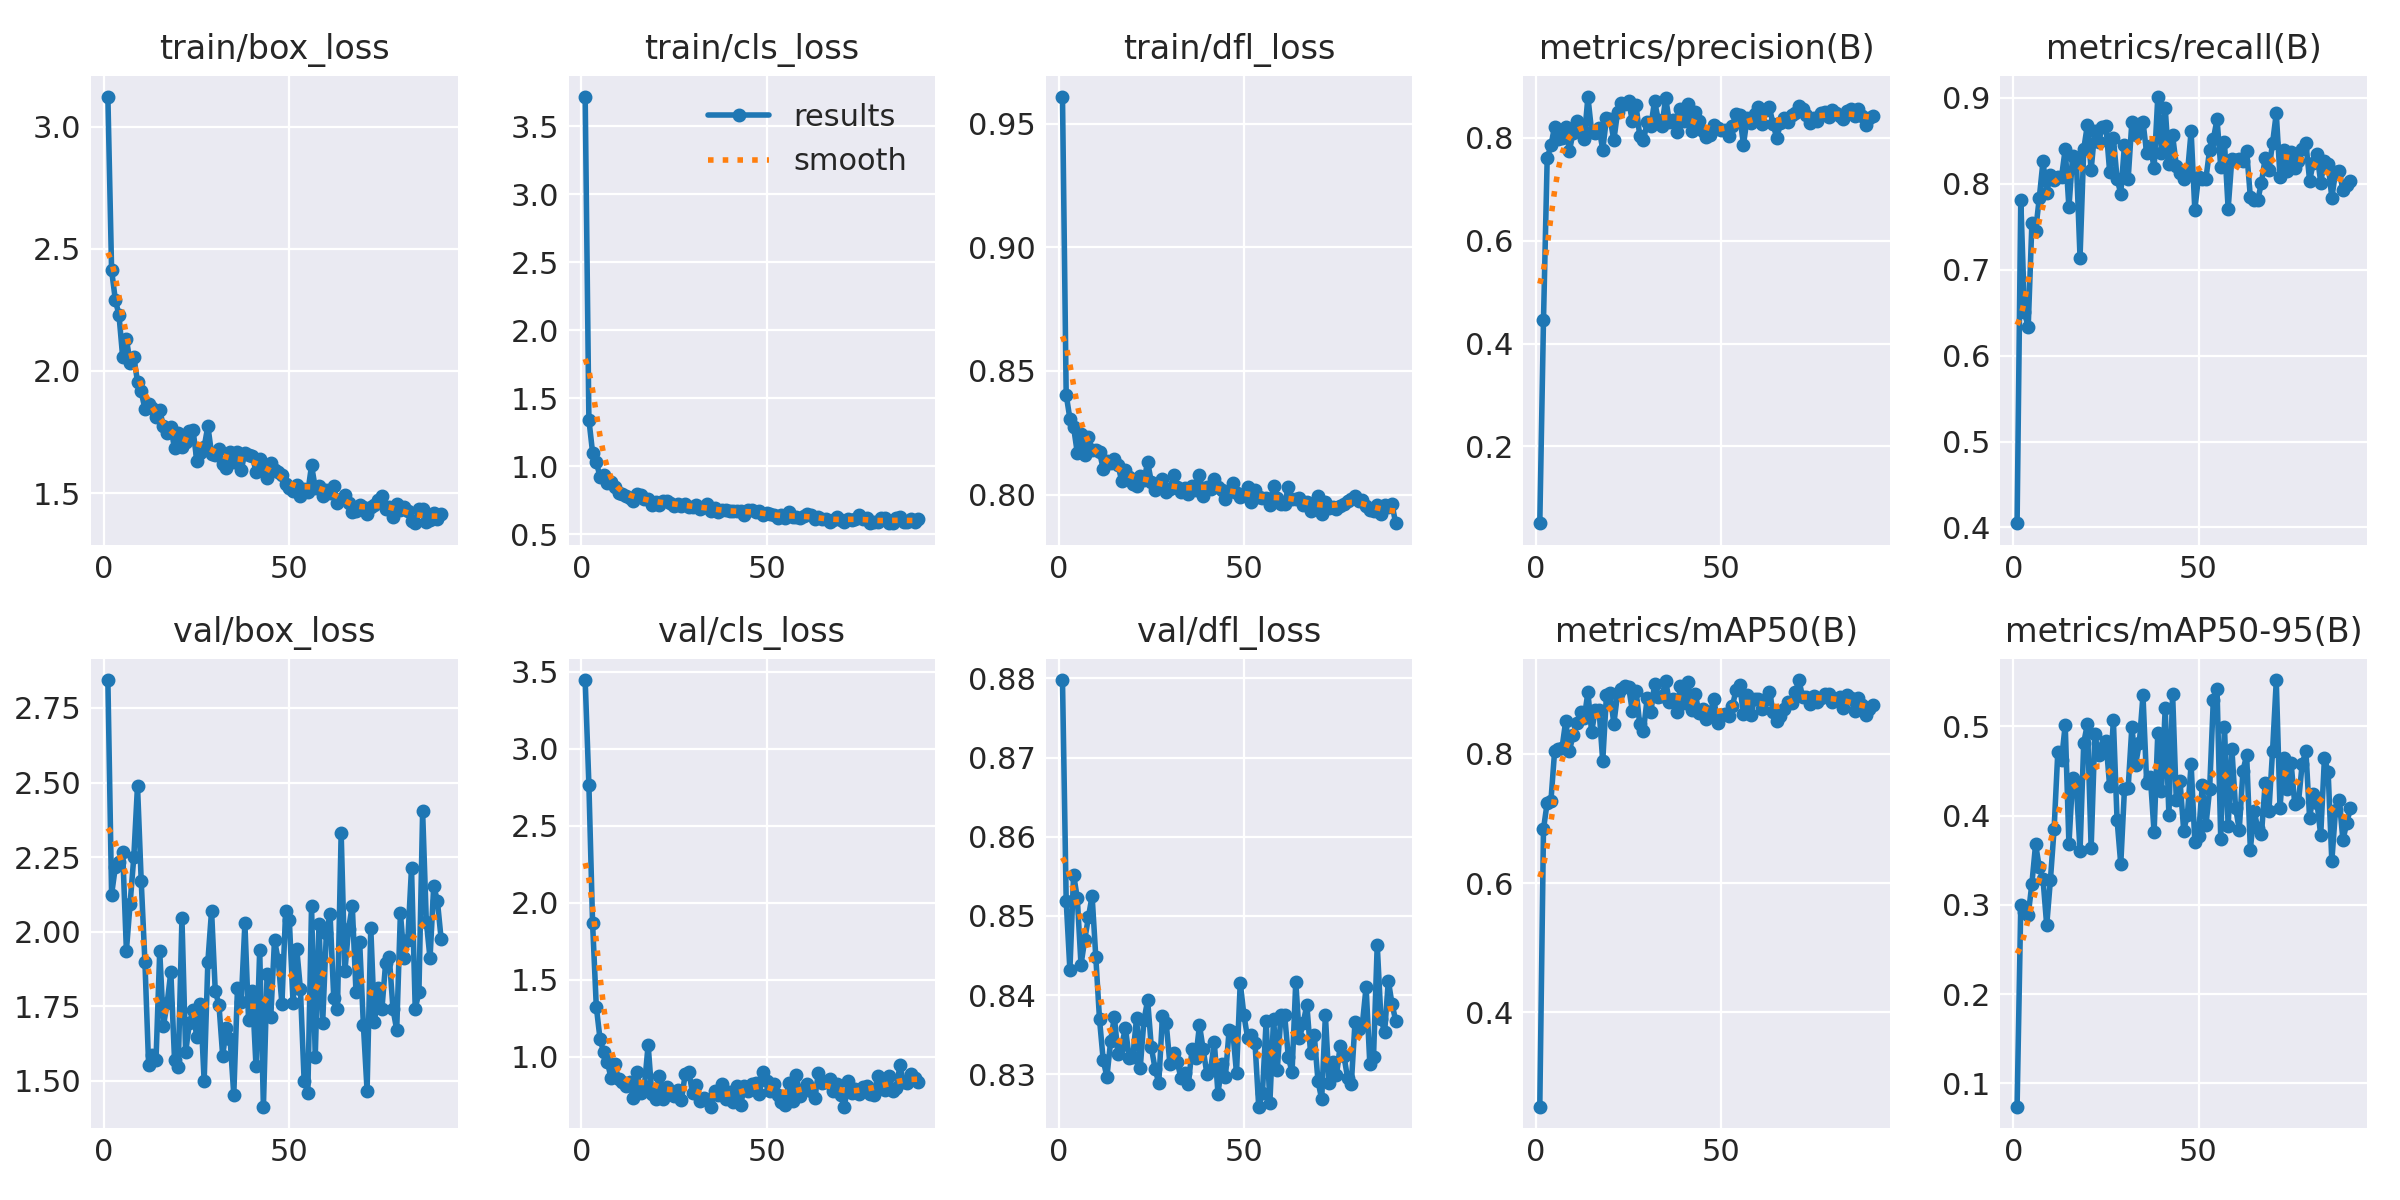

In [20]:
# Display results plot
results_plot = trainer.experiment_dir / "results.png"

if results_plot.exists():
    print("Training Curves:")
    display(Image(filename=str(results_plot), width=1200))
else:
    print("Results plot not found. Check the training output directory.")

### 📉 Loss Curves Analysis

In [21]:
# Load and plot training history
results_csv = trainer.experiment_dir / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    
    # Plot key metrics
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Training loss
    if 'train/box_loss' in df.columns:
        axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Box Loss', linewidth=2)
        axes[0, 0].plot(df['epoch'], df['train/cls_loss'], label='Class Loss', linewidth=2)
        axes[0, 0].plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss', linewidth=2)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training Losses')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    
    # mAP curves
    if 'metrics/mAP50(B)' in df.columns:
        axes[0, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5', linewidth=2, color='green')
        axes[0, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', linewidth=2, color='blue')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('mAP')
        axes[0, 1].set_title('Mean Average Precision')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    
    # Precision/Recall
    if 'metrics/precision(B)' in df.columns:
        axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', linewidth=2, color='orange')
        axes[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', linewidth=2, color='purple')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].set_title('Precision and Recall')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Learning rate
    if 'lr/pg0' in df.columns:
        axes[1, 1].plot(df['epoch'], df['lr/pg0'], linewidth=2, color='red')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_title('Learning Rate Schedule')
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    print("\nFinal Epoch Metrics:")
    print("-" * 50)
    last_row = df.iloc[-1]
    print(f"Precision:    {last_row['metrics/precision(B)']:.4f}")
    print(f"Recall:       {last_row['metrics/recall(B)']:.4f}")
    print(f"mAP@0.5:      {last_row['metrics/mAP50(B)']:.4f}")
    print(f"mAP@0.5:0.95: {last_row['metrics/mAP50-95(B)']:.4f}")
    print("-" * 50)
else:
    print("Results CSV not found")

<Figure size 1500x1000 with 4 Axes>


Final Epoch Metrics:
--------------------------------------------------
Precision:    0.8426
Recall:       0.8037
mAP@0.5:      0.8753
mAP@0.5:0.95: 0.4081
--------------------------------------------------


### 🎯 Confusion Matrix

In [22]:
# Display confusion matrices
confusion_matrix = trainer.experiment_dir / "confusion_matrix.png"
confusion_matrix_norm = trainer.experiment_dir / "confusion_matrix_normalized.png"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if confusion_matrix.exists():
    img1 = plt.imread(str(confusion_matrix))
    axes[0].imshow(img1)
    axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0].axis('off')

if confusion_matrix_norm.exists():
    img2 = plt.imread(str(confusion_matrix_norm))
    axes[1].imshow(img2)
    axes[1].set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 2 Axes>

### 📊 Precision-Recall Curves

In [23]:
# Display PR curve and other curves
pr_curve = trainer.experiment_dir / "PR_curve.png"
f1_curve = trainer.experiment_dir / "F1_curve.png"
p_curve = trainer.experiment_dir / "P_curve.png"
r_curve = trainer.experiment_dir / "R_curve.png"

curves = [
    (pr_curve, 'Precision-Recall Curve'),
    (f1_curve, 'F1-Confidence Curve'),
    (p_curve, 'Precision-Confidence Curve'),
    (r_curve, 'Recall-Confidence Curve'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (curve_path, title) in enumerate(curves):
    if curve_path.exists():
        img = plt.imread(str(curve_path))
        axes[idx].imshow(img)
        axes[idx].set_title(title, fontsize=11, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

<Figure size 1400x1200 with 4 Axes>

## 🎉 Training Complete!

### Next Steps:

1. ✅ **Model saved** at: `outputs/weights/{experiment_name}_best.pt`
2. ⏭️ **Proceed to evaluation**: Run `03_model_evaluation.ipynb`
3. 📊 **Or run evaluation script**: `python models/evaluate.py --model path/to/best.pt`

### What You've Achieved:

- ✅ Trained YOLOv8 on thermal waterfowl data
- ✅ Achieved mAP@0.5 of **[check results above]**
- ✅ Saved best model weights
- ✅ Generated training curves and metrics
- ✅ Ready for comprehensive evaluation!

## 💾 Save Training Info

Let's save key information for the presentation.

In [24]:
import json

# Create training summary
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    last_row = df.iloc[-1]
    
    training_summary = {
        'experiment_name': trainer.experiment_name,
        'model': config.YOLO_MODEL,
        'epochs_trained': int(last_row['epoch']),
        'final_metrics': {
            'precision': float(last_row['metrics/precision(B)']),
            'recall': float(last_row['metrics/recall(B)']),
            'mAP50': float(last_row['metrics/mAP50(B)']),
            'mAP50_95': float(last_row['metrics/mAP50-95(B)']),
        },
        'model_path': str(config.WEIGHTS_PATH / f"{trainer.experiment_name}_best.pt"),
        'training_time': 'approximately 1-2 hours',
    }
    
    summary_file = trainer.experiment_dir / 'training_summary.json'
    with open(summary_file, 'w') as f:
        json.dump(training_summary, f, indent=2)
    
    print("Training Summary:")
    print(json.dumps(training_summary, indent=2))
    print(f"\n✓ Summary saved to: {summary_file}")
else:
    print("Could not create summary - results.csv not found")

Training Summary:
{
  "experiment_name": "waterfowl_yolov8n_20251105_121108",
  "model": "yolov8n.pt",
  "epochs_trained": 91,
  "final_metrics": {
    "precision": 0.84264,
    "recall": 0.80367,
    "mAP50": 0.87535,
    "mAP50_95": 0.40806
  },
  "model_path": "/home/code/CV_1/notebooks/../outputs/weights/waterfowl_yolov8n_20251105_121108_best.pt",
  "training_time": "approximately 1-2 hours"
}

✓ Summary saved to: /home/code/CV_1/notebooks/../outputs/weights/waterfowl_yolov8n_20251105_121108/training_summary.json
